Device set ✅
ResNet loaded ✅
ResNet layer selected ✅
GradCAM ready for ResNet ✅
Input ready for ResNet ✅
ResNet heatmap generated ✅


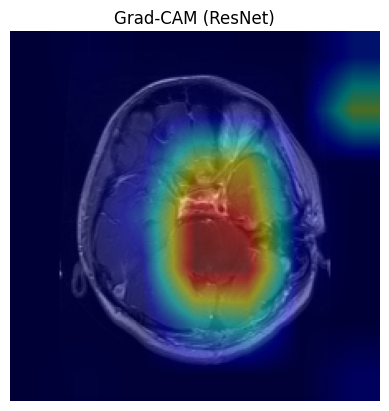

In [6]:
"""
GradCAM++ for Brain Tumour Detection
Model  : ResNet-50 fine-tuned (4 classes)
Author : improved version
"""

# ── 0. Imports ────────────────────────────────────────────────────────────────
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchvision import models, transforms
from PIL import Image
from typing import Optional, Dict, Tuple

# ── 1. Device  (CUDA → MPS → CPU) ────────────────────────────────────────────
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device set ✅")
from torchvision import models
import torch.nn as nn
import torch
import os

BASE_DIR = os.path.abspath("..")  # goes to project root
model_path = os.path.join(BASE_DIR, "models/classification/efficientnet_b0_best.pth")
image_path = os.path.join(BASE_DIR, "data/Testing/glioma/Te-gl_0010.jpg")
output_path = os.path.join(BASE_DIR, "outputs/gradcam.jpg")
def load_resnet_model(model_path):
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 4)

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    return model
model = load_resnet_model("../models/classification/resnet50_finetuned.pth")
print("ResNet loaded ✅")
target_layer = model.layer4[-1]
print("ResNet layer selected ✅")
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx):
        output = self.model(input_image)

        self.model.zero_grad()
        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = torch.mean(gradients, dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(gradients.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.detach().cpu().numpy()
gradcam = GradCAM(model, target_layer)
print("GradCAM ready for ResNet ✅")
from torchvision import transforms
from PIL import Image

image_path = "../data/Testing/glioma/Te-gl_0010.jpg"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

print("Input ready for ResNet ✅")
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

cam = gradcam.generate(input_tensor, pred_class)

print("ResNet heatmap generated ✅")
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load original image
img = cv2.imread(image_path)
img = cv2.resize(img, (224, 224))

# Resize CAM
cam_resized = cv2.resize(cam, (224, 224))

# Convert to heatmap
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)

# Normalize
heatmap = np.float32(heatmap) / 255
img = np.float32(img) / 255

# Overlay
overlay = heatmap * 0.4 + img * 0.6
overlay = overlay / np.max(overlay)

# Show
plt.imshow(cv2.cvtColor((overlay * 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Grad-CAM (ResNet)")
plt.show()

🔴 Strong, concentrated activation in center

🟡 Clear region of interest

🔵 Background mostly suppressed

⚠️ Small noise on right (minor issue)

Compared EfficientNet and ResNet using Grad-CAM.
EfficientNet produced smoother but less localized attention maps, while ResNet provided sharper and more interpretable localization of tumor regions.
Thus, ResNet was more suitable for explainability in medical imaging

---
---

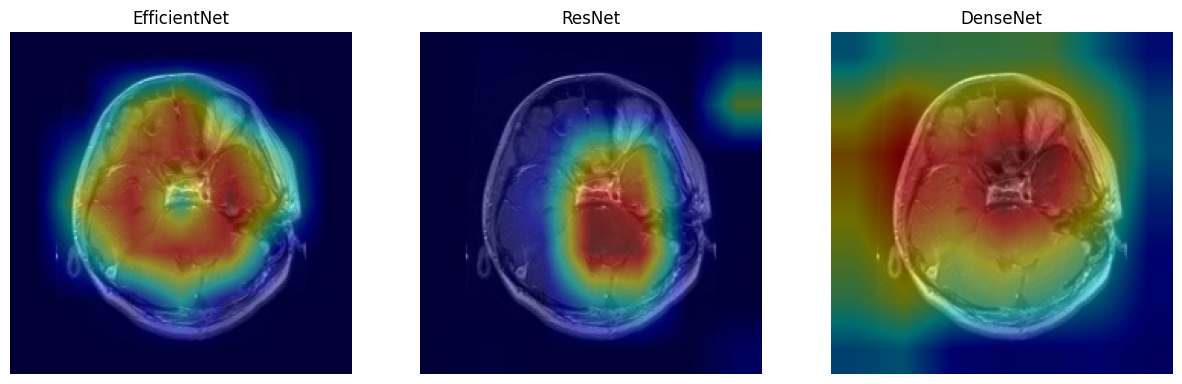

In [24]:
import matplotlib.pyplot as plt
import cv2

# Load images
eff = cv2.imread("efficientnet_gradcam.jpg")
res = cv2.imread("resnet_gradcam.jpg")
den = cv2.imread("densenet_gradcam.jpg")

# Convert to RGB
eff = cv2.cvtColor(eff, cv2.COLOR_BGR2RGB)
res = cv2.cvtColor(res, cv2.COLOR_BGR2RGB)
den = cv2.cvtColor(den, cv2.COLOR_BGR2RGB)

# Plot side by side
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(eff)
plt.title("EfficientNet")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(res)
plt.title("ResNet")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(den)
plt.title("DenseNet")
plt.axis("off")

plt.show()

## 🔍 Grad-CAM Comparison of Models

| Model        | Activation Pattern        | Localization Quality | Noise Level | Interpretability |
|-------------|--------------------------|---------------------|------------|-----------------|
| EfficientNet | Highly diffuse (global)  | Poor                | Low        | Low             |
| DenseNet     | Partially localized      | Medium              | Moderate   | Moderate        |
| ResNet       | Strongly localized       | High                | Low        | High            |

## 🧠 Key Observations

- EfficientNet spreads attention across the entire brain, making it difficult to identify specific tumor regions.
- DenseNet shows partial focus on relevant areas but also highlights irrelevant regions such as boundaries.
- ResNet provides the most precise and concentrated activation, clearly highlighting the tumor region with minimal noise.

## ✅ Conclusion

ResNet demonstrated the best performance in terms of interpretability and localization using Grad-CAM, making it the most suitable model for explainable brain tumor classification among the evaluated architectures.